In [ ]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from pathlib import Path
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

2025-09-15 07:15:06.350149: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:






INPUT_A = "/Users/mac1/Documents/Final 2/gestures.csv"         
INPUT_B = "/Users/mac1/chopnow/dataset/gestures.csv"         
OUTPUT_MERGED = "/Users/mac1/chopnow/dataset/gestures2.csv"  



TAG_A = "A"
TAG_B = "B"


DEDUP_MODE = "exact"     
ROUND_DECIMALS = 4       
LABEL_MODE = "union"     
REQUIRE_HAND = None     

FEAT_COLS = [f"f{i}" for i in range(63)]
META_COLS = ["label", "subject", "session", "timestamp_ms", "handedness"]

def load_csv(path, tag):
    df = pd.read_csv(path)
    missing = [c for c in META_COLS + FEAT_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing columns: {missing}")
    df["dataset_id"] = tag
    return df

def deduplicate(df: pd.DataFrame) -> pd.DataFrame:
    if DEDUP_MODE == "none":
        print("[dedup] none")
        return df
    if DEDUP_MODE == "exact":
        before = len(df)
        df2 = df.drop_duplicates(subset=FEAT_COLS, keep="first")
        print(f"[dedup] exact: dropped {before - len(df2)} duplicates")
        return df2
    if DEDUP_MODE == "rounded":
        before = len(df)
        rounded = df[FEAT_COLS].round(ROUND_DECIMALS)
        key = pd.util.hash_pandas_object(rounded, index=False)
        df2 = df.loc[~key.duplicated()].copy()
        print(f"[dedup] rounded({ROUND_DECIMALS}): dropped {before - len(df2)} near-dupes")
        return df2
    raise ValueError("DEDUP_MODE must be 'none', 'exact', or 'rounded'.")

def align_labels_union_or_intersection(dfA, dfB):
    if LABEL_MODE == "union":
        return dfA, dfB
    if LABEL_MODE == "intersection":
        inter = set(dfA["label"].unique()) & set(dfB["label"].unique())
        if not inter:
            raise ValueError("No common labels across A and B.")
        kept = sorted(list(inter))
        print(f"[labels] intersection kept: {kept}")
        return dfA[dfA["label"].isin(kept)].copy(), dfB[dfB["label"].isin(kept)].copy()
    raise ValueError("LABEL_MODE must be 'union' or 'intersection'.")

def summary(df: pd.DataFrame, title: str):
    print(f"\n== {title} ==")
    print("Total rows:", len(df))
    print("Labels:", sorted(df["label"].unique().tolist()))
    print("Per label:\n", df["label"].value_counts().sort_index())
    print("\nPer dataset_id:\n", df["dataset_id"].value_counts())

def main():
    # --- load ---
    dfA = load_csv(INPUT_A, TAG_A)
    dfB = load_csv(INPUT_B, TAG_B)
    print(f"[load] A: {len(dfA)} rows, B: {len(dfB)} rows")

    # --- optional handedness filter ---
    if REQUIRE_HAND in ("Left", "Right"):
        dfA = dfA[dfA["handedness"] == REQUIRE_HAND].copy()
        dfB = dfB[dfB["handedness"] == REQUIRE_HAND].copy()
        print(f"[filter] kept only handedness={REQUIRE_HAND}")

    # --- label alignment ---
    dfA, dfB = align_labels_union_or_intersection(dfA, dfB)

    # --- merge & dedup ---
    merged = pd.concat([dfA, dfB], ignore_index=True)
    print(f"[merge] combined rows: {len(merged)}")
    merged = deduplicate(merged)

    # --- summary & save ---
    summary(merged, "Merged summary")

    out_path = Path(OUTPUT_MERGED)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    merged.to_csv(out_path, index=False)
    print(f"\n[SAVED] {out_path.resolve()}")

if __name__ == "__main__":
    main()


[load] A: 3811 rows, B: 4861 rows
[merge] combined rows: 8672
[dedup] exact: dropped 0 duplicates

== Merged summary ==
Total rows: 8672
Labels: ['backward', 'forward', 'left', 'right', 'stop']
Per label:
 label
backward    1533
forward     2178
left        1552
right       1639
stop        1770
Name: count, dtype: int64

Per dataset_id:
 dataset_id
B    4861
A    3811
Name: count, dtype: int64

[SAVED] /Users/mac1/chopnow/dataset/gestures2.csv


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,773 (65.52 KB)

 Trainable params: 16,773 (65.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5308 - loss: 1.1671 - val_accuracy: 0.9777 - val_loss: 0.2146
Epoch 2/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9352 - loss: 0.2460 - val_accuracy: 0.9791 - val_loss: 0.0751
Epoch 3/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9630 - loss: 0.1311 - val_accuracy: 0.9928 - val_loss: 0.0376
Epoch 4/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9828 - loss: 0.0709 - val_accuracy: 0.9921 - val_loss: 0.0344
Epoch 5/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9826 - loss: 0.0673 - val_accuracy: 0.9921 - val_loss: 0.0188
Epoch 6/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9893 - loss: 0.0428 - val_accuracy: 0.9856 - val_loss: 0.0473
Epoch 7/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9899 - loss: 0.0424 - val_accuracy: 0.9971 - val_loss: 0.0124
Epoch 8/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0337 - val_accuracy: 0.

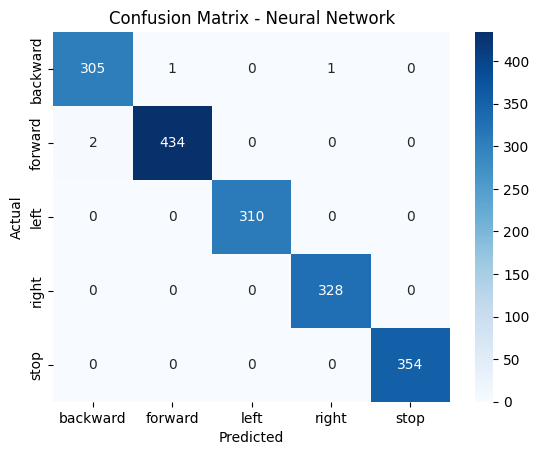

Model saved to gesture_nn_model.h5


In [ ]:


# Load the dataset
df = pd.read_csv("/Users/mac1/chopnow/dataset/gestures2.csv")

# Prepare X and y
X = df[[f"f{i}" for i in range(63)]].values
y = df["label"].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

# ------------------ Neural Network ------------------
model = Sequential([
    Dense(128, activation='relu', input_shape=(63,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_categorical.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ------------------ Train ------------------
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=1)

# ------------------ Evaluate (NO ROUNDING) ------------------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nRaw Test Accuracy (no rounding): {acc}")  # full raw float
print(f"Raw Test Loss: {loss}")  # full raw float

# ------------------ Predictions ------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# ------------------ Raw Accuracy Check ------------------
acc_manual = accuracy_score(y_true, y_pred)
print(f"Manual Accuracy from sklearn: {acc_manual}")  # full raw float

# ------------------ Full Precision Classification Report ------------------
print("\nClassification Report (not rounded):")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=10))

# ------------------ Confusion Matrix ------------------
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Neural Network")
plt.show()

# ------------------ Save Model ------------------
model.save("gesture_nn_model.h5")
print("Model saved to gesture_nn_model.h5")


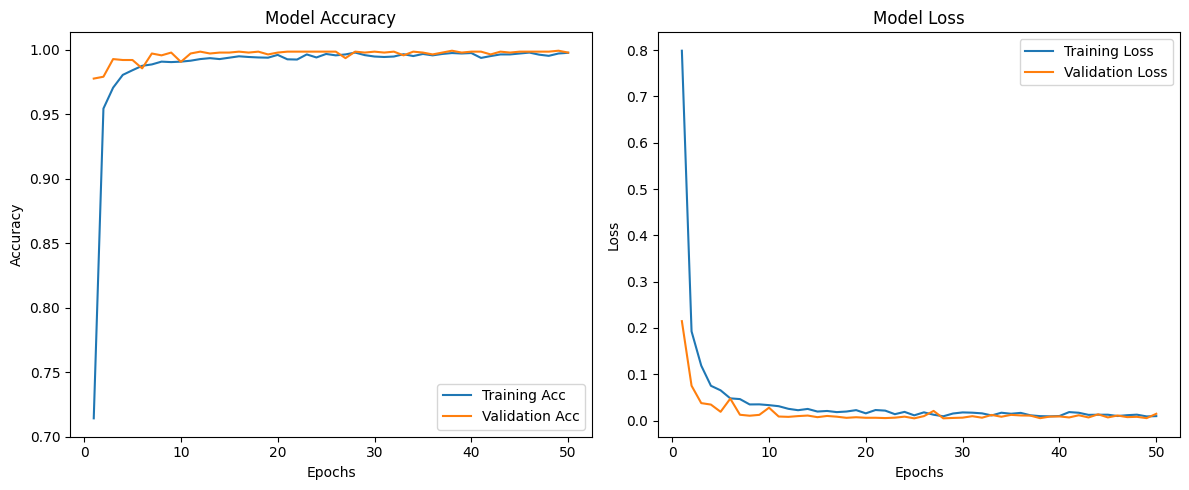

In [41]:
# ------------------ Plot Training History ------------------
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Accuracy plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Acc')
    plt.plot(epochs, val_acc, label='Validation Acc')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function
plot_history(history)


In [38]:
from sklearn.metrics import precision_score

# Macro-average precision (equal weight to each class)
macro_precision = precision_score(y_true, y_pred, average='macro')
print(f"Macro-average Precision: {macro_precision:.10f}")

# Weighted-average precision (weighted by support/instances per class)
weighted_precision = precision_score(y_true, y_pred, average='weighted')
print(f"Weighted-average Precision: {weighted_precision:.10f}")

# Per-class precision (no averaging)
per_class_precision = precision_score(y_true, y_pred, average=None)
for label_idx, class_name in enumerate(le.classes_):
    print(f"Precision for class '{class_name}': {per_class_precision[label_idx]:.10f}")


Macro-average Precision: 0.9976293956
Weighted-average Precision: 0.9976949514
Precision for class 'backward': 0.9934853420
Precision for class 'forward': 0.9977011494
Precision for class 'left': 1.0000000000
Precision for class 'right': 0.9969604863
Precision for class 'stop': 1.0000000000


In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

# ---- Precision ----
precision_macro = precision_score(y_true, y_pred, average='macro')
precision_weighted = precision_score(y_true, y_pred, average='weighted')
precision_per_class = precision_score(y_true, y_pred, average=None)

print(f"Macro Precision:   {precision_macro:.10f}")
print(f"Weighted Precision:{precision_weighted:.10f}")
print("Per-class Precision:")
for idx, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {precision_per_class[idx]:.10f}")

# ---- Recall ----
recall_macro = recall_score(y_true, y_pred, average='macro')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
recall_per_class = recall_score(y_true, y_pred, average=None)

print(f"\nMacro Recall:   {recall_macro:.10f}")
print(f"Weighted Recall:{recall_weighted:.10f}")
print("Per-class Recall:")
for idx, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {recall_per_class[idx]:.10f}")

# ---- F1-Score ----
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
f1_per_class = f1_score(y_true, y_pred, average=None)

print(f"\nMacro F1-score:   {f1_macro:.10f}")
print(f"Weighted F1-score:{f1_weighted:.10f}")
print("Per-class F1-score:")
for idx, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {f1_per_class[idx]:.10f}")


Macro Precision:   0.9976293956
Weighted Precision:0.9976949514
Per-class Precision:
  backward: 0.9934853420
  forward: 0.9977011494
  left: 1.0000000000
  right: 0.9969604863
  stop: 1.0000000000

Macro Recall:   0.9977796372
Weighted Recall:0.9976945245
Per-class Recall:
  backward: 0.9934853420
  forward: 0.9954128440
  left: 1.0000000000
  right: 1.0000000000
  stop: 1.0000000000

Macro F1-score:   0.9977037910
Weighted F1-score:0.9976939705
Per-class F1-score:
  backward: 0.9934853420
  forward: 0.9965556831
  left: 1.0000000000
  right: 0.9984779300
  stop: 1.0000000000


In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Get confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Per-class accuracy = correct predictions / total actual samples for that class
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Print results
for idx, class_name in enumerate(le.classes_):
    print(f"Accuracy for class '{class_name}': {per_class_accuracy[idx]:.10f}")


Accuracy for class 'backward': 0.9934853420
Accuracy for class 'forward': 0.9954128440
Accuracy for class 'left': 1.0000000000
Accuracy for class 'right': 1.0000000000
Accuracy for class 'stop': 1.0000000000
